# PD Business Impact – Book Stats, Net Return on Exposure & Threshold Sensitivity

**Purpose:** Demonstrate business impact of the trained PD model using out-of-time test set: approval/charge-off rates, **net return on exposure** (NIM-style spread on approved balances, not capital-based RoE), and threshold sensitivity. Compares **baseline (approve all)** vs **model at selected threshold**.

This notebook has **two parts**, each with the same business-impact focus but different data and models:

| Part | Notebook | What you get |
|------|----------|--------------|
| **I – Home Credit** | `00_pd_homecredit_lstm_kaggle.ipynb` | **Behavioral model** (LSTM on repayment sequences): business impact, approval/CoR/net return on exposure, threshold sensitivity. |
| **II – LendingClub** | `02a_pd_xgboost_training.ipynb` (+ `01`) | **Application scorecard** (XGBoost/LR): full book stats and net return on exposure on OOT test. Run 01 and 02a first. |

**Assumption – Cost of funds:** I use **cost_of_funds = 3.0%** as a reasonable assumption for the cost at which the bank funds the loans (e.g. wholesale funding). This is documented here and used in net return on exposure calculations (Part II). Change the constant in code if your environment uses a different rate.


## Part I – Home Credit: Business impact 

`00_pd_homecredit_lstm_kaggle.ipynb`<br>
**Purpose:** Demonstrate business impact of the trained PD model (triple-stream LSTM) using the OOT run from notebook 00: metrics that inform **approval/charge-off rates, net return on exposure, and threshold sensitivity** (LSTM vs baseline). Same context as Part II; inputs come from 00’s pipeline.

**Inputs (from pipeline):** Run `00_pd_homecredit_lstm_kaggle.ipynb` on Kaggle and download outputs. For OOT predictions, this demo first reads `homecredit_oot_predictions.parquet/csv` from `kaggle_outputs/` or `data/home_credit/` (full cohort). Embedded notebook JSON is fallback only and ignored if it is a tiny sample. On Kaggle, `metrics_summary.json` is ephemeral, so metrics are still read from notebook cell output.

**Context:** Data = Kaggle Home Credit Default Risk; model = triple-stream LSTM vs LR/LightGBM (static only); OOT via `SK_ID_CURR`; segments = has_bureau / no_bureau, repayment-bureau (see 00 for methodology).

---


Loaded metrics from 00 notebook (notebook cell output)



,value
baseline_auc,0.743388
baseline_ks,0.380925
epochs_trained,30.000000
f1_05,0.262379
lstm_auc,0.746911
lstm_gini,0.493823
lstm_ks,0.376163
opt_f1,0.290882
opt_threshold,0.590000
precision_05,0.161546



List-valued keys (length): {'best_val_auc_by_epoch': 30}


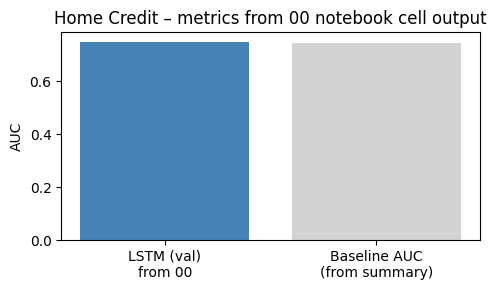

In [102]:
import json
import os
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    display = print

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent

def _load_homecredit_metrics_from_notebook():
    """Load metrics from 00 notebook cell output (works when notebook is downloaded from Kaggle)."""
    for nb_name in ["00_pd_homecredit_lstm_kaggle.ipynb", "00-pd-homecredit-lstm-kaggle.ipynb"]:
        for base in [ROOT / "notebooks", ROOT]:
            nb_path = base / nb_name
            if not nb_path.is_file():
                continue
            try:
                with open(nb_path, encoding="utf-8") as f:
                    nb = json.load(f)
                for c in nb.get("cells", []):
                    for o in c.get("outputs", []):
                        if o.get("output_type") != "display_data" or "data" not in o:
                            continue
                        d = o["data"]
                        if "application/json" not in d:
                            continue
                        raw = d["application/json"]
                        if isinstance(raw, dict) and "homecredit_metrics_summary" in raw:
                            m = raw["homecredit_metrics_summary"]
                            # Reject metrics from local tiny-data runs (epochs < 10 and auc < 0.60 is a clear signal)
                            if float(m.get("lstm_auc", 0)) < 0.60 or float(m.get("baseline_auc", 0)) < 0.60:
                                continue   # skip this notebook — looks like a local test run
                            return m, "notebook cell output"
            except Exception:
                pass
    return None, None

raw, src = _load_homecredit_metrics_from_notebook()
if raw is None:
    print("No Home Credit metrics found.")
    print("After running 00_pd_homecredit_lstm_kaggle.ipynb on Kaggle, download the notebook and")
    print("place it in notebooks/ as 00_pd_homecredit_lstm_kaggle.ipynb. The demo reads metrics")
    print("from the notebook's cell output (embedded JSON). metrics_summary.json is not used.")
else:
    scalars = {k: v for k, v in raw.items() if not isinstance(v, (list, dict))}
    lists = {k: len(v) for k, v in raw.items() if isinstance(v, list)}
    print(f"Loaded metrics from 00 notebook ({src})\n")
    if scalars:
        import pandas as pd
        display(pd.DataFrame([scalars]).T.rename(columns={0: "value"}))
    else:
        print(json.dumps(raw, indent=2)[:3000])
    if lists:
        print("\nList-valued keys (length):", lists)
    import matplotlib.pyplot as plt
    if "lstm_auc" in raw and "baseline_auc" in raw:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.bar(["LSTM (val)\nfrom 00", "Baseline AUC\n(from summary)"], [raw["lstm_auc"], raw["baseline_auc"]], color=["steelblue", "lightgray"])
        ax.set_ylabel("AUC")
        ax.set_title("Home Credit – metrics from 00 notebook cell output")
        plt.tight_layout()
        plt.show()

## Part I – Business impact (book stats, net return on exposure, threshold sensitivity)

To mirror Part II, this section computes the same business-impact views using **OOT predictions from notebook 00's cell output**.

Place Kaggle outputs locally after running notebook 00. This section first loads full `homecredit_oot_predictions.parquet/csv` artifacts (preferred), and only falls back to embedded notebook JSON when it contains a full export.

### Economic assumptions (used only when optional fields are missing)

- `COST_OF_FUNDS = 3.0%` (same as Part II)
- `ASSUMED_INT_RATE = 12.0%`
- `ASSUMED_TERM_MONTHS = 36`
- `LGD = 100%` (charge-off equals principal for defaults)

---

**Assumption sensitivity (directional):**

| Assumption | Base | Stressed | Impact on net return |
|---|---|---|---|
| Cost of funds | 3.0% | 4.5% | −1.5 pp per annum on net spread |
| Interest rate (assumed) | **24.0% APR (fixed proxy)** | 20.0% | −4.0 pp gross yield |
| LGD | 100% | 60% | Charge-off impact reduces 40%; net return improves for same CoR |
| Loan term | 36 months | 24 months | Shorter term reduces total interest earned; higher annualised spread if rate unchanged |


**Note on Home Credit interest rate:** Home Credit does not publish per-loan contracted
rates in the public competition dataset. `AMT_ANNUITY * 12 / AMT_CREDIT` overstates
yield (produces ~54% flat rate) because it ignores principal amortisation. A fixed
24% APR proxy is used, consistent with Home Credit's disclosed effective rates in
emerging markets (20–35% range). Part II (LendingClub) uses actual `int_rate` from
the dataset, so no assumption is needed there.

**Note on LGD:** 100% LGD is a conservative assumption (zero recovery). In practice,
secured consumer lending (e.g. goods-backed POS loans) may achieve 30–50% recovery.
For provisioning under IFRS 9, institution-specific LGD curves calibrated from
historical recovery data would replace this constant.


**Note on portfolio size (Part I):** `loan_amnt` in the OOT parquet is raw
`AMT_CREDIT` from the Home Credit dataset, which is denominated in **Russian
roubles** — not USD. The OOT cohort of ~61,500 loans therefore shows a portfolio
face value in the tens of billions when labelled with `$`. The net return
percentages, CoR, and charge-off ratios are unaffected (they are ratios of the same
currency). Absolute dollar figures in Part I are illustrative only; a production
analysis would convert to a single reporting currency using the exchange rate at
origination date.


Loaded Home Credit OOT predictions: 00 notebook (artifact file: c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\kaggle_outputs\homecredit_oot_predictions.parquet) (n=61,502)
[Baseline (approve all)] Approval rate: 100.00% | CoR: 7.36% | Weighted avg int rate: 24.00% | Weighted avg term (mo): 36.0
  Interest earned ($m): 26619.29 | Interest paid ($m): 3327.41 | Charge-off ($m): 2721.74
  Banking profit ($m): 20570.13 | Net return on exposure: 55.64%

Chosen threshold (max banking profit under policy constraints): 0.80

[Model (threshold=0.80)] Approval rate: 97.07% | CoR: 6.69% | Weighted avg int rate: 24.00% | Weighted avg term (mo): 36.0
  Interest earned ($m): 26005.21 | Interest paid ($m): 3250.65 | Charge-off ($m): 2415.78
  Banking profit ($m): 20338.78 | Net return on exposure: 56.31%


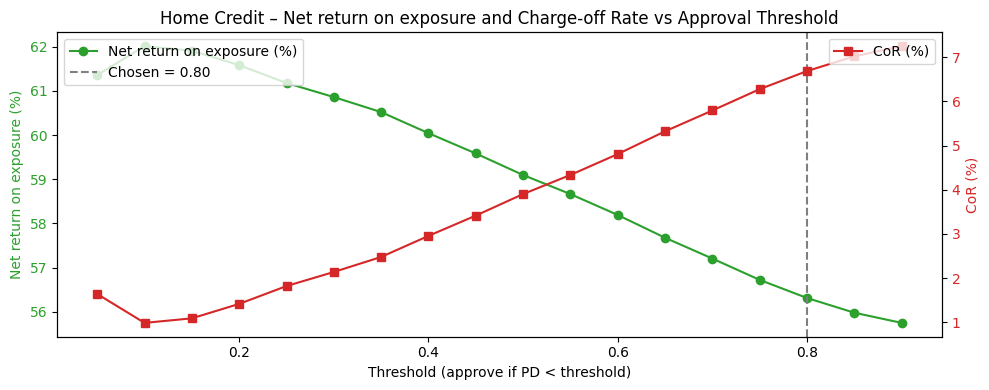


Business case (OOT test cohort)
  $ Loans approved – Baseline: $36971.23m  |  Model: $36118.34m
  $ Charge-offs saved (vs baseline): $305.96m
  Net return on exposure – Baseline: 55.64%  |  Model: 56.31%  |  Improvement: +0.67 pp

Summary:
At threshold 0.80, the model approves 97% of applications, reducing CoR from 7.4% (baseline) to 6.7%, improving net return on exposure from 55.6% to 56.3%, saving approximately $306.0m in charge-offs on the test cohort.
[HomeCredit 4stream (homecredit_oot_predictions_4stream.parquet) | Baseline (approve all)] Approval rate: 100.00% | CoR: 7.36% | Weighted avg int rate: 24.00% | Weighted avg term (mo): 36.0
  Interest earned ($m): 26619.29 | Interest paid ($m): 3327.41 | Charge-off ($m): 2721.74
  Banking profit ($m): 20570.13 | Net return on exposure: 55.64%
[HomeCredit 4stream (homecredit_oot_predictions_4stream.parquet) | Model (t=0.80)] Approval rate: 97.07% | CoR: 6.69% | Weighted avg int rate: 24.00% | Weighted avg term (mo): 36.0
  Interest ea

In [103]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

COST_OF_FUNDS = 3.0
ASSUMED_INT_RATE = 12.0
ASSUMED_TERM_MONTHS = 36
LGD = 1.0

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent

def _load_homecredit_from_files():
    """Load full Home Credit OOT predictions from parquet/csv artifacts first."""
    _cwd = Path.cwd()
    candidate_paths = [
        _cwd / "kaggle_outputs" / "homecredit_oot_predictions.parquet",
        _cwd.parent / "kaggle_outputs" / "homecredit_oot_predictions.parquet",
        ROOT / "kaggle_outputs" / "homecredit_oot_predictions.parquet",
        ROOT / "data" / "home_credit" / "homecredit_oot_predictions.parquet",
        ROOT / "notebooks" / "homecredit_oot_predictions.parquet",
        _cwd / "kaggle_outputs" / "homecredit_oot_predictions.csv",
        _cwd.parent / "kaggle_outputs" / "homecredit_oot_predictions.csv",
        ROOT / "kaggle_outputs" / "homecredit_oot_predictions.csv",
        ROOT / "data" / "home_credit" / "homecredit_oot_predictions.csv",
        ROOT / "notebooks" / "homecredit_oot_predictions.csv",
    ]
    for p in candidate_paths:
        if not p.is_file():
            continue
        try:
            if p.suffix.lower() == ".parquet":
                df = pd.read_parquet(p)
            else:
                df = pd.read_csv(p)
            if len(df) >= 1000:
                return df, f"artifact file: {p}"
        except Exception:
            pass
    return None, None

def _load_homecredit_from_notebook():
    """Fallback loader: parse embedded JSON output from downloaded 00 notebook."""
    for nb_name in ["00_pd_homecredit_lstm_kaggle.ipynb", "00-pd-homecredit-lstm-kaggle.ipynb"]:
        for base in [ROOT / "notebooks", ROOT]:
            nb_path = base / nb_name
            if not nb_path.is_file():
                continue
            try:
                with open(nb_path, encoding="utf-8") as f:
                    nb = json.load(f)
                for c in nb.get("cells", []):
                    for o in c.get("outputs", []):
                        if o.get("output_type") != "display_data" or "data" not in o:
                            continue
                        d = o["data"]
                        if "application/json" not in d:
                            continue
                        raw = d["application/json"]
                        if isinstance(raw, dict) and "homecredit_oot_predictions" in raw:
                            recs = raw["homecredit_oot_predictions"]
                            if recs:
                                df = pd.DataFrame(recs)
                                if len(df) >= 1000:
                                    return df, "notebook cell output (full export)"
                                # Many notebooks embed head(5) only; reject tiny samples for policy analysis.
                                continue
            except Exception:
                pass
    return None, None

dfp, src = _load_homecredit_from_files()
if dfp is None:
    dfp, src = _load_homecredit_from_notebook()
source_msg = f"00 notebook ({src})" if dfp is not None else ""

if dfp is None:
    print("No Home Credit OOT predictions found.")
    print("Run 00_pd_homecredit_lstm_kaggle.ipynb on Kaggle and download outputs.")
    print("Expected full files: homecredit_oot_predictions.parquet/csv under kaggle_outputs/ or data/home_credit/.")
    print("Fallback notebook JSON is used only if it contains a full export (>=1000 rows).")
else:

    # normalize column names
    cols = {c.lower(): c for c in dfp.columns}
    pd_col = cols.get("pd") or cols.get("p") or cols.get("p_pred") or cols.get("pred")
    y_col = cols.get("y_true") or cols.get("y") or cols.get("label") or cols.get("default")
    if pd_col is None or y_col is None:
        raise ValueError(f"Prediction file must include pd and y_true columns. Found: {list(dfp.columns)}")

    dfp = dfp.rename(columns={pd_col: "pd", y_col: "y_true"})
    dfp["pd"] = pd.to_numeric(dfp["pd"], errors="coerce")
    dfp["y_true"] = pd.to_numeric(dfp["y_true"], errors="coerce").astype(int)
    dfp = dfp.dropna(subset=["pd", "y_true"]).reset_index(drop=True)

    # Optional economics fields
    if "loan_amnt" not in dfp.columns:
        dfp["loan_amnt"] = 1.0  # unit exposure
    if "int_rate" not in dfp.columns:
        dfp["int_rate"] = ASSUMED_INT_RATE
    if "term_months" not in dfp.columns:
        dfp["term_months"] = ASSUMED_TERM_MONTHS

    dfp["loan_amnt"] = pd.to_numeric(dfp["loan_amnt"], errors="coerce").fillna(1.0)
    dfp["int_rate"] = pd.to_numeric(dfp["int_rate"], errors="coerce").fillna(ASSUMED_INT_RATE)
    dfp["term_months"] = pd.to_numeric(dfp["term_months"], errors="coerce").fillna(ASSUMED_TERM_MONTHS)

    print(f"Loaded Home Credit OOT predictions: {source_msg} (n={len(dfp):,})")

    def book_stats_generic(dfp: pd.DataFrame, threshold: float, label: str):
        # approve if PD < threshold
        approved = dfp["pd"].to_numpy() < threshold
        amnt = dfp.loc[approved, "loan_amnt"].sum()
        charge_off = dfp.loc[approved & (dfp["y_true"] == 1), "loan_amnt"].sum() * LGD
        n_total = len(dfp)
        n_app = int(approved.sum())
        approval_rate = n_app / n_total if n_total else 0.0
        CoR = charge_off / amnt if amnt else 0.0

        app = dfp.loc[approved]
        wgt_int_rate = (app["int_rate"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0
        wgt_term = (app["term_months"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0

        interest_earned = amnt * (wgt_int_rate / 100.0) * (wgt_term / 12.0)
        interest_paid = amnt * (COST_OF_FUNDS / 100.0) * (wgt_term / 12.0)
        banking_profit = interest_earned - interest_paid - charge_off
        net_ret = (banking_profit / amnt * 100.0) if amnt else 0.0

        print(f"[{label}] Approval rate: {approval_rate:.2%} | CoR: {CoR:.2%} | Weighted avg int rate: {wgt_int_rate:.2f}% | Weighted avg term (mo): {wgt_term:.1f}")
        print(f"  Interest earned ($m): {interest_earned/1e6:.2f} | Interest paid ($m): {interest_paid/1e6:.2f} | Charge-off ($m): {charge_off/1e6:.2f}")
        print(f"  Banking profit ($m): {banking_profit/1e6:.2f} | Net return on exposure: {net_ret:.2f}%")
        return {
            "approved_amnt": float(amnt),
            "charged_off_amnt": float(charge_off),
            "approval_rate": float(approval_rate),
            "CoR": float(CoR),
            "net_return_pct": float(net_ret),
            "wgt_int_rate": float(wgt_int_rate),
            "wgt_term": float(wgt_term),
            "n_approved": int(n_app),
        }

    # Baseline: approve all
    baseline_stats = book_stats_generic(dfp, threshold=1.0, label="Baseline (approve all)")

    # Choose threshold on this OOT file by maximising banking profit (economic objective).
    # Guardrails avoid degenerate policies (e.g., approving ~all loans at very high thresholds).
    # Note: for strict governance, pick threshold on validation and lock before final OOT reporting.
    thresholds = np.arange(0.05, 0.95, 0.05)

    def _stats_only(df, thresh):
        approved = df["pd"].to_numpy() < thresh
        amnt = df.loc[approved, "loan_amnt"].sum()
        charge_off = df.loc[approved & (df["y_true"] == 1), "loan_amnt"].sum() * LGD
        app = df.loc[approved]
        wgt_int_rate = (app["int_rate"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0
        wgt_term = (app["term_months"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0
        interest_earned = amnt * (wgt_int_rate / 100.0) * (wgt_term / 12.0)
        interest_paid = amnt * (COST_OF_FUNDS / 100.0) * (wgt_term / 12.0)
        banking_profit = interest_earned - interest_paid - charge_off
        net_ret = (banking_profit / amnt * 100.0) if amnt else 0.0
        return {
            "approval_rate": approved.sum() / len(df),
            "CoR": charge_off / amnt if amnt else 0.0,
            "net_return_pct": net_ret,
            "banking_profit": banking_profit,
        }

    rows = []
    best_t, best_profit = 0.5, -np.inf
    for t in thresholds:
        stats = _stats_only(dfp, float(t))
        rows.append({"threshold": float(t), **{k: stats[k] for k in ("approval_rate", "CoR", "net_return_pct")}, "banking_profit": stats["banking_profit"]})
        if stats["banking_profit"] > best_profit:
            best_profit, best_t = float(stats["banking_profit"]), float(t)

    # Constrained policy choice for interview-defensible business decisions.
    # - keep approval rate below 98% (avoid approve-all behavior)
    # - require CoR not worse than baseline
    policy_rows = [
        r for r in rows
        if (r["approval_rate"] <= 0.98) and (r["CoR"] <= baseline_stats["CoR"])
    ]
    if policy_rows:
        best_policy = max(policy_rows, key=lambda r: r["banking_profit"])
        best_t = float(best_policy["threshold"])
        policy_note = "max banking profit under policy constraints"
    else:
        policy_note = "max banking profit (no feasible constrained threshold)"

    print(f"\nChosen threshold ({policy_note}): {best_t:.2f}\n")

    model_stats = book_stats_generic(dfp, threshold=best_t, label=f"Model (threshold={best_t:.2f})")

    # Threshold sensitivity (reuse threshold sweep above)
    sens = pd.DataFrame(rows)

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(sens["threshold"], sens["net_return_pct"], marker="o", color="tab:green", label="Net return on exposure (%)")
    ax1.set_xlabel("Threshold (approve if PD < threshold)")
    ax1.set_ylabel("Net return on exposure (%)", color="tab:green")
    ax1.tick_params(axis="y", labelcolor="tab:green")
    ax1.axvline(x=best_t, color="gray", linestyle="--", label=f"Chosen = {best_t:.2f}")

    ax2 = ax1.twinx()
    ax2.plot(sens["threshold"], sens["CoR"] * 100.0, marker="s", color="tab:red", label="CoR (%)")
    ax2.set_ylabel("CoR (%)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title("Home Credit – Net return on exposure and Charge-off Rate vs Approval Threshold")
    plt.tight_layout()
    plt.show()

    # Business case (mirrors Part II)
    approved_baseline = float(baseline_stats["approved_amnt"])
    approved_model = float(model_stats["approved_amnt"])
    charged_off_baseline = float(baseline_stats["charged_off_amnt"])
    charged_off_model = float(model_stats["charged_off_amnt"])
    saved_charge_off = charged_off_baseline - charged_off_model
    net_ret_baseline_pct = baseline_stats["net_return_pct"]
    net_ret_model_pct = model_stats["net_return_pct"]
    net_ret_improvement_pp = net_ret_model_pct - net_ret_baseline_pct
    print("\nBusiness case (OOT test cohort)")
    print(f"  $ Loans approved – Baseline: ${approved_baseline/1e6:.2f}m  |  Model: ${approved_model/1e6:.2f}m")
    print(f"  $ Charge-offs saved (vs baseline): ${saved_charge_off/1e6:.2f}m")
    print(f"  Net return on exposure – Baseline: {net_ret_baseline_pct:.2f}%  |  Model: {net_ret_model_pct:.2f}%  |  Improvement: {net_ret_improvement_pp:+.2f} pp")
    print("\nSummary:")
    if net_ret_improvement_pp >= 0:
        net_ret_phrase = f"improving net return on exposure from {net_ret_baseline_pct:.1f}% to {net_ret_model_pct:.1f}%"
    else:
        net_ret_phrase = f"changing net return on exposure from {net_ret_baseline_pct:.1f}% to {net_ret_model_pct:.1f}% (down {abs(net_ret_improvement_pp):.1f} pp)"
    summary = (
        f"At threshold {best_t:.2f}, the model approves {model_stats['approval_rate']:.0%} of applications, "
        f"reducing CoR from {baseline_stats['CoR']:.1%} (baseline) to {model_stats['CoR']:.1%}, "
        f"{net_ret_phrase}, "
        f"saving approximately ${saved_charge_off/1e6:.1f}m in charge-offs on the test cohort."
    )
    print(summary)

    # --- Optional: compare multiple exported stream variants (single run) ---
    def _normalize_homecredit_df(_df: pd.DataFrame) -> pd.DataFrame:
        _df = _df.copy()
        cols = {c.lower(): c for c in _df.columns}
        pd_col = cols.get('pd') or cols.get('p') or cols.get('p_pred') or cols.get('pred')
        y_col = cols.get('y_true') or cols.get('y') or cols.get('label') or cols.get('default')
        if pd_col is None or y_col is None:
            raise ValueError(f"Prediction file must include pd and y_true columns. Found: {list(_df.columns)}")
        _df = _df.rename(columns={pd_col: 'pd', y_col: 'y_true'})
        _df['pd'] = pd.to_numeric(_df['pd'], errors='coerce')
        _df['y_true'] = pd.to_numeric(_df['y_true'], errors='coerce').astype(int)
        _df = _df.dropna(subset=['pd', 'y_true']).reset_index(drop=True)

        # Optional economics fields
        if 'loan_amnt' not in _df.columns:
            _df['loan_amnt'] = 1.0
        if 'int_rate' not in _df.columns:
            _df['int_rate'] = ASSUMED_INT_RATE
        if 'term_months' not in _df.columns:
            _df['term_months'] = ASSUMED_TERM_MONTHS

        _df['loan_amnt'] = pd.to_numeric(_df['loan_amnt'], errors='coerce').fillna(1.0)
        _df['int_rate'] = pd.to_numeric(_df['int_rate'], errors='coerce').fillna(ASSUMED_INT_RATE)
        _df['term_months'] = pd.to_numeric(_df['term_months'], errors='coerce').fillna(ASSUMED_TERM_MONTHS)
        return _df

    def _evaluate_policy(_df: pd.DataFrame, label: str) -> dict:
        _df = _normalize_homecredit_df(_df)
        base = book_stats_generic(_df, threshold=1.0, label=f"{label} | Baseline (approve all)")

        thresholds = np.arange(0.05, 0.95, 0.05)
        rows = []
        for t in thresholds:
            st = _stats_only(_df, float(t))
            rows.append({
                'threshold': float(t),
                'approval_rate': float(st['approval_rate']),
                'CoR': float(st['CoR']),
                'net_return_pct': float(st['net_return_pct']),
                'banking_profit': float(st['banking_profit']),
            })
        policy_rows = [r for r in rows if (r['approval_rate'] <= 0.98) and (r['CoR'] <= base['CoR'])]
        if policy_rows:
            best = max(policy_rows, key=lambda r: r['banking_profit'])
            policy_note = 'profit_max (constraints)'
        else:
            best = max(rows, key=lambda r: r['banking_profit'])
            policy_note = 'profit_max (unconstrained)'

        model = book_stats_generic(_df, threshold=float(best['threshold']), label=f"{label} | Model (t={best['threshold']:.2f})")
        return {
            'variant': label,
            'policy': policy_note,
            't': float(best['threshold']),
            'approval_rate': float(model['approval_rate']),
            'CoR': float(model['CoR']),
            'net_return_pct': float(model['net_return_pct']),
            'net_ret_pp_vs_baseline': float(model['net_return_pct'] - base['net_return_pct']),
            'chargeoffs_saved_m': float((base['charged_off_amnt'] - model['charged_off_amnt']) / 1e6),
            'profit_m': float(best['banking_profit'] / 1e6),
            'n': int(len(_df)),
        }

    # Try to load the explicit variant parquets if they exist.
    variant_paths = []
    for base_dir in [ROOT / 'kaggle_outputs', Path.cwd() / 'kaggle_outputs', Path.cwd().parent / 'kaggle_outputs']:
        variant_paths.extend([
            (base_dir / 'homecredit_oot_predictions_4stream.parquet', '4stream'),
            (base_dir / 'homecredit_oot_predictions_3stream_no_bureau.parquet', '3stream_no_bureau'),
        ])

    seen = set()
    compare_rows = []
    for p, tag in variant_paths:
        if str(p) in seen:
            continue
        seen.add(str(p))
        if not p.is_file():
            continue
        try:
            _dfv = pd.read_parquet(p)
            compare_rows.append(_evaluate_policy(_dfv, f"HomeCredit {tag} ({p.name})"))
        except Exception as e:
            print(f"[WARN] Could not evaluate variant {p}: {e}")

    if compare_rows:
        print("\nVariant comparison (same economics + same policy constraints):")
        compare_df = pd.DataFrame(compare_rows)
        # compact formatting
        compare_df['approval_rate'] = compare_df['approval_rate'].map(lambda x: round(x, 4))
        compare_df['CoR'] = compare_df['CoR'].map(lambda x: round(x, 4))
        compare_df['net_return_pct'] = compare_df['net_return_pct'].map(lambda x: round(x, 2))
        compare_df['net_ret_pp_vs_baseline'] = compare_df['net_ret_pp_vs_baseline'].map(lambda x: round(x, 2))
        compare_df['chargeoffs_saved_m'] = compare_df['chargeoffs_saved_m'].map(lambda x: round(x, 2))
        compare_df['profit_m'] = compare_df['profit_m'].map(lambda x: round(x, 2))
        print(compare_df[['variant','policy','t','approval_rate','CoR','net_return_pct','net_ret_pp_vs_baseline','chargeoffs_saved_m','profit_m','n']].to_string(index=False))


### Part I – Threshold sensitivity (Home Credit OOT)

Sweep threshold over predicted PD to show approval rate and CoR trade-off.
Assumes economic parameters from Cell 3 (`ASSUMED_INT_RATE`, `ASSUMED_TERM_MONTHS`,
`COST_OF_FUNDS`, `LGD`). Uses OOT predictions loaded above.
Policy constraint: CoR ≤ 8% (Home Credit is higher-risk / no-bureau segment),
Approval ≥ 40%.


In [104]:
# Part I – Threshold sensitivity (Home Credit)
# Runs when dfp (OOT predictions) is loaded with columns: y_true, pd

HC_COR_CEILING    = 0.08
# Home Credit cohort: baseline CoR ~8%; 8% ceiling is tight but achievable.
# LendingClub Part II uses 14% ceiling (baseline CoR 16.6% -- early-vintage higher-risk cohort).
HC_APPROVAL_FLOOR = 0.40

if 'dfp' in dir() and dfp is not None and len(dfp) >= 1000:
    _y_true = np.asarray(dfp["y_true"]).ravel()
    _p_prob = np.asarray(dfp["pd"]).ravel()
    _n      = len(_y_true)
    _rows   = []
    for _t in np.arange(0.10, 0.90, 0.05):
        _approved = _p_prob < _t
        _n_app    = _approved.sum()
        _app_rate = _n_app / _n
        _co_rate  = _y_true[_approved].mean() if _n_app > 0 else 0.0
        # Net return (simplified: use assumed int rate, no per-loan actuals)
        _int_earn = 1.0 * (ASSUMED_INT_RATE / 100) * (ASSUMED_TERM_MONTHS / 12)
        _int_paid = 1.0 * (COST_OF_FUNDS   / 100) * (ASSUMED_TERM_MONTHS / 12)
        _net_ret  = (_int_earn - _int_paid - _co_rate * LGD) * 100
        _rows.append({"threshold": round(_t, 2), "approval_rate": _app_rate,
                      "CoR": _co_rate, "net_return_pct": _net_ret})
    hc_sens_df = pd.DataFrame(_rows)

    # net_return_pct is cumulative over ASSUMED_TERM_MONTHS (not annualised NIM).
    # Annualised equivalent = net_return_pct / (ASSUMED_TERM_MONTHS / 12)
    hc_sens_df["net_return_ann_pct"] = hc_sens_df["net_return_pct"] / (ASSUMED_TERM_MONTHS / 12)

    # Policy-constrained optimum
    _feasible = hc_sens_df[
        (hc_sens_df["CoR"] <= HC_COR_CEILING) &
        (hc_sens_df["approval_rate"] >= HC_APPROVAL_FLOOR)
    ]
    if len(_feasible) > 0:
        _best = _feasible.loc[_feasible["net_return_pct"].idxmax()]
        print(f"Policy threshold (CoR≤{HC_COR_CEILING:.0%}, Appr≥{HC_APPROVAL_FLOOR:.0%}): {_best['threshold']:.2f}")
        print(f"  Approval rate: {_best['approval_rate']:.1%} | CoR: {_best['CoR']:.2%} | "
          f"Net return cumulative: {_best['net_return_pct']:.2f}% | "
          f"Net return annualised: {_best['net_return_pct'] / (ASSUMED_TERM_MONTHS/12):.2f}%")
    else:
        print(f"No threshold satisfies CoR≤{HC_COR_CEILING:.0%} AND Approval≥{HC_APPROVAL_FLOOR:.0%}. Review constraints.")

    print("\nHome Credit threshold sensitivity:")
    print(hc_sens_df.round(4).to_string(index=False))
else:
    print("[Part I threshold sensitivity] Skipped: dfp not loaded or insufficient rows.")
    print("  Run 00_pd_homecredit_lstm_kaggle.ipynb on Kaggle and place outputs in kaggle_outputs/.")


Policy threshold (CoR≤8%, Appr≥40%): 0.35
  Approval rate: 44.5% | CoR: 2.49% | Net return cumulative: 24.51% | Net return annualised: 8.17%

Home Credit threshold sensitivity:
 threshold  approval_rate    CoR  net_return_pct  net_return_ann_pct
      0.10         0.0218 0.0089         26.1058              8.7019
      0.15         0.0737 0.0121         25.7872              8.5957
      0.20         0.1525 0.0140         25.6028              8.5343
      0.25         0.2468 0.0182         25.1818              8.3939
      0.30         0.3473 0.0210         24.8980              8.2993
      0.35         0.4449 0.0249         24.5114              8.1705
      0.40         0.5350 0.0292         24.0823              8.0274
      0.45         0.6148 0.0338         23.6203              7.8734
      0.50         0.6872 0.0389         23.1126              7.7042
      0.55         0.7537 0.0437         22.6273              7.5424
      0.60         0.8156 0.0490         22.0975              7.

---

## Part II – LendingClub: PD Business Impact – Book Stats, net return on exposure & Threshold Sensitivity

**Purpose:** Demonstrate business impact of the trained PD model using out-of-time test set: approval/charge-off rates, net return on exposure, and threshold sensitivity. Compares **baseline (approve all)** vs **model at selected threshold**.

**Inputs (from pipeline):** Trained model (`pd_model_local_v2.pkl`), test set from `lendingclub_engineered.parquet` (with `loan_amnt`, `int_rate`, `term_months` for business metrics). Run **01** and **02a** first so the parquet includes `loan_amnt` and `int_rate` (01 saves them for this demo).

**Assumption – Cost of funds:** I use **cost_of_funds = 3.0%** as a reasonable assumption for the cost at which the bank funds the loans (e.g. wholesale funding). This is documented here and used in net return on exposure calculations. Change the constant in code if your environment uses a different rate.

### Part II – 1. Load trained model and test set


In [105]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent
if not (ROOT / "credit_risk").is_dir():
    raise RuntimeError("Run this notebook from the repo root or notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage_v2
from credit_risk.feature_engineering.feature_screening import screen_features_train_only

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
MODEL_PATH = ROOT / "models" / "pd" / "pd_model_local_v2.pkl"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01_pd_lendingclub_feature_engineering.ipynb first.")
if not MODEL_PATH.exists():
    raise FileNotFoundError("Run 02a_pd_xgboost_training.ipynb and save the model first.")

df = pd.read_parquet(DATA_PATH)
for col in ["loan_amnt", "int_rate"]:
    if col not in df.columns:
        raise ValueError(f"Parquet missing '{col}'. Re-run 01 to add loan_amnt and int_rate for the demo.")

all_feature_names = get_feature_names_no_leakage_v2()
X = df[[c for c in all_feature_names if c in df.columns]].copy()
y = df["default"]
for c in all_feature_names:
    if c not in X.columns:
        X[c] = 0.0
X = X[all_feature_names]

test_idx = df["split"] == "test"
X_test = X[test_idx]
y_test = y[test_idx]
df_test = df[test_idx].copy()

# Feature screening (same as 02a): use train to get selected features
train_idx = df["split"] == "train"
X_train = X[train_idx]
y_train = y[train_idx]
screening = screen_features_train_only(X_train, y_train, missingness_threshold=0.50, min_ks=0.001, corr_threshold=0.95)
feature_names = screening.selected_features
X_test_filled = X_test[feature_names].copy()
medians = X_train[feature_names].median()
X_test_filled = X_test_filled.fillna(medians)

model_data = joblib.load(MODEL_PATH)
final_model = model_data["model"]
best_threshold_opt = float(model_data.get("best_threshold", 0.5))

# Governance note: best_threshold_opt loaded from training artefact (selected on val set in 02a).
# For audit trail: re-derive here from validation split to confirm consistency.
# This block is informational — it prints the val-derived threshold for comparison.
try:
    train_mask = df["split"] == "train"
    val_mask   = df["split"] == "val"
    if val_mask.sum() > 0:
        X_val_filled = X[val_mask][feature_names].fillna(X[train_mask][feature_names].median())
        y_val        = y[val_mask]
        p_val        = final_model.predict_proba(X_val_filled)[:, 1]
        from sklearn.metrics import f1_score as _f1
        _thresholds  = np.arange(0.1, 0.9, 0.01)
        _f1_scores   = [_f1(y_val, (p_val >= t).astype(int), zero_division=0) for t in _thresholds]
        val_derived_threshold = float(_thresholds[np.argmax(_f1_scores)])
        print(f"[Governance check] Val-derived threshold (max F1): {val_derived_threshold:.2f}")
        print(f"[Governance check] Loaded threshold from artefact : {best_threshold_opt:.2f}")
        if abs(val_derived_threshold - best_threshold_opt) > 0.05:
            print("[WARNING] Threshold discrepancy > 0.05 pp — review 02a threshold selection.")
    else:
        import warnings
        warnings.warn(
            "[GOVERNANCE] No 'val' split found in lendingclub_engineered.parquet. "
            "Cannot independently verify best_threshold_opt. "
            "Re-run 01_pd_lendingclub_feature_engineering.ipynb to ensure val split is present.",
            UserWarning,
            stacklevel=2,
        )
        print("[GOVERNANCE WARNING] No 'val' split found -- artefact threshold used without verification.")
        print("  Action required: re-run 01 to add a val split column to the parquet.")
except Exception as _e:
    print(f"[Governance check] Skipped: {_e}")
p_test = final_model.predict_proba(X_test_filled)[:, 1]

# Business df: loan_amnt, int_rate, term (months)
term_col = "term_months" if "term_months" in df_test.columns else "term"
if term_col not in df_test.columns:
    raise ValueError("Parquet missing term_months/term. Re-run 01.")
loans_df = df_test[["loan_amnt", "int_rate", term_col]].rename(columns={term_col: "term"})
if loans_df["term"].dtype == object:
    loans_df["term"] = pd.to_numeric(loans_df["term"].astype(str).str.replace(r" months?", "", regex=True), errors="coerce")
loans_df = loans_df.astype(float, errors="ignore")

n_test = len(y_test)
print(f"Test set: {n_test:,} loans. Optimal threshold (from model pkl): {best_threshold_opt:.3f}")


[Governance check] Val-derived threshold (max F1): 0.29
[Governance check] Loaded threshold from artefact : 0.29
Test set: 21,721 loans. Optimal threshold (from model pkl): 0.290


### Part II – 2. Book stats and net return on exposure helpers


In [106]:
def book_stats(loans_df, p_prob, threshold, label, y_true):
    """
    Approved = loans where p_prob < threshold (predicted non-default).
    CoR = charged-off amount / approved amount.
    Uses reset_index to guarantee positional alignment between loans_df and arrays.
    """
    loans_df = loans_df.reset_index(drop=True)
    y_true   = np.asarray(y_true).ravel()
    p_prob   = np.asarray(p_prob).ravel()

    approved_mask     = p_prob < threshold
    default_mask      = y_true == 1
    charged_off_mask  = approved_mask & default_mask

    approved_amnt    = loans_df.loc[approved_mask, "loan_amnt"].sum()
    charged_off_amnt = loans_df.loc[charged_off_mask, "loan_amnt"].sum()
    n_approved       = approved_mask.sum()
    n_total          = len(loans_df)
    approval_rate    = n_approved / n_total if n_total else 0
    CoR              = charged_off_amnt / approved_amnt if approved_amnt else 0

    app = loans_df.loc[approved_mask]
    wgt_int      = (app["int_rate"] * app["loan_amnt"]).sum()
    wgt_int_rate = wgt_int / approved_amnt if approved_amnt else 0
    term_col     = "term_months" if "term_months" in app.columns else "term"
    wgt_term     = (app[term_col] * app["loan_amnt"]).sum() / approved_amnt if approved_amnt else 0

    print(f"\n{label}")
    print(f"  Approved: {n_approved:,} / {n_total:,}  ({approval_rate:.1%})")
    print(f"  Approved $: ${approved_amnt/1e6:.2f}m | Charged-off $: ${charged_off_amnt/1e6:.2f}m | CoR: {CoR:.2%}")
    print(f"  Wtd avg int rate: {wgt_int_rate:.2f}% | Wtd avg term: {wgt_term:.1f} months")

    return {
        "approved_amnt":    approved_amnt,
        "charged_off_amnt": charged_off_amnt,
        "n_approved":       n_approved,
        "n_total":          n_total,
        "approval_rate":    approval_rate,
        "CoR":              CoR,
        "wgt_int_rate":     wgt_int_rate,
        "wgt_term":         wgt_term,
    }


In [107]:
def net_return_pct(approved_amnt, charge_off_amnt, wgt_int_rate, wgt_term, cost_of_funds=3.0):
    """
    Net return on approved exposure (NIM proxy / net spread).

    Formula: (interest_earned - interest_paid - charge_off) / approved_exposure * 100

    This is a CUMULATIVE return over the weighted average loan term (not annualised NIM).
    To compare across books with different tenors, use the annualised figure below.

    NOTE: This is NOT Return on Equity (RoE). True RoE divides by regulatory capital
    (e.g. 8-12% of RWA under Basel standardised approach). This metric approximates
    net spread on the approved book at the deal level.
    """
    interest_earned = approved_amnt * (wgt_int_rate / 100) * (wgt_term / 12)
    interest_paid = approved_amnt * (cost_of_funds / 100) * (wgt_term / 12)
    banking_profit = interest_earned - interest_paid - charge_off_amnt
    cumul_ret_pct = (banking_profit / approved_amnt * 100) if approved_amnt else 0
    term_yrs = (wgt_term / 12) if wgt_term > 0 else 1.0
    ann_ret_pct = cumul_ret_pct / term_yrs
    scale = 1e6
    print(f"  Interest earned ($m): {interest_earned/scale:.2f} | "
          f"Interest paid ($m): {interest_paid/scale:.2f} | "
          f"Charge-off ($m): {charge_off_amnt/scale:.2f}")
    print(f"  Net spread profit ($m): {banking_profit/scale:.2f} | "
          f"Net return (cumulative, {wgt_term:.0f}mo): {cumul_ret_pct:.2f}% | "
          f"Net return (annualised): {ann_ret_pct:.2f}%")
    return cumul_ret_pct   # return cumulative for backward compat with downstream calcs


### Part II – 3. Baseline book stats (approve all – no model)

Baseline = approve every loan (threshold 1.0, so all applications are "approved").

In [108]:
COST_OF_FUNDS = 3.0  # % (documented assumption)
# Baseline: approve all (threshold=1.0 so p_test < 1.0 for every loan)
baseline_stats = book_stats(loans_df, p_test, threshold=1.0, label="Baseline (approve all)", y_true=y_test.values)
net_return_pct(
    baseline_stats["approved_amnt"],
    baseline_stats["charged_off_amnt"],
    baseline_stats["wgt_int_rate"],
    baseline_stats["wgt_term"],
    cost_of_funds=COST_OF_FUNDS,
)



Baseline (approve all)
  Approved: 21,721 / 21,721  (100.0%)
  Approved $: $261.68m | Charged-off $: $43.36m | CoR: 16.57%
  Wtd avg int rate: 13.22% | Wtd avg term: 47.8 months
  Interest earned ($m): 137.90 | Interest paid ($m): 31.28 | Charge-off ($m): 43.36
  Net spread profit ($m): 63.26 | Net return (cumulative, 48mo): 24.17% | Net return (annualised): 6.07%


np.float64(24.173158633911676)

### Part II – 4. Model book stats at optimal threshold

In [109]:
model_stats = book_stats(loans_df, p_test, threshold=best_threshold_opt, label=f"Model (threshold={best_threshold_opt:.2f})", y_true=y_test.values)
net_return_pct(
    model_stats["approved_amnt"],
    model_stats["charged_off_amnt"],
    model_stats["wgt_int_rate"],
    model_stats["wgt_term"],
    cost_of_funds=COST_OF_FUNDS,
)



Model (threshold=0.29)
  Approved: 18,466 / 21,721  (85.0%)
  Approved $: $215.25m | Charged-off $: $30.37m | CoR: 14.11%
  Wtd avg int rate: 12.69% | Wtd avg term: 47.0 months
  Interest earned ($m): 106.98 | Interest paid ($m): 25.29 | Charge-off ($m): 30.37
  Net spread profit ($m): 51.32 | Net return (cumulative, 47mo): 23.84% | Net return (annualised): 6.09%


np.float64(23.84069650307459)

### Part II – 5. Threshold sensitivity analysis

Sweep threshold from 0.2 to 0.80 (step 0.05). For each threshold: approval rate,
Charge-off Rate (CoR), net return on exposure, AUC-ROC, F1, recall (TPR), precision.

**Policy constraint approach:** Rather than selecting purely on F1 (a model metric),
production threshold selection applies business constraints first:
- **CoR ceiling**: maximum acceptable charge-off rate. Set to **14%** for this
  LendingClub OOT cohort (baseline CoR = 16.6%; 14% represents a meaningful
  improvement while remaining achievable at high approval rates). A prime
  portfolio would use a tighter ceiling (e.g. 3–6%); the appropriate value
  depends on the lender's risk appetite and product type.
- **Approval floor**: minimum portfolio coverage required. Set to **80%** to
  ensure the policy threshold retains most of the book while still screening
  the highest-risk applicants.

Within the feasible set satisfying both constraints, the threshold maximising net
return on exposure is selected. The F1-optimal threshold is also shown for
comparison with the model-selection criterion used in training.


In [110]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

thresholds = np.arange(0.2, 0.81, 0.05)
auc_roc = roc_auc_score(y_test, p_test)
y_vals = np.asarray(y_test).ravel()
p_arr = np.asarray(p_test).ravel()
loans_df_reset = loans_df.reset_index(drop=True)
rows = []
for t in thresholds:
    approved_mask = p_arr < t
    default_mask = y_vals == 1
    chargedoff_mask = approved_mask & default_mask

    app = loans_df_reset.loc[approved_mask]
    approved_amnt = app["loan_amnt"].sum()
    charged_off_amnt = loans_df_reset.loc[chargedoff_mask, "loan_amnt"].sum()
    n_approved = int(approved_mask.sum())
    approval_rate = n_approved / len(y_vals)
    CoR = charged_off_amnt / approved_amnt if approved_amnt else 0

    wgt_int = (app["int_rate"] * app["loan_amnt"]).sum()
    wgt_int_rate = wgt_int / approved_amnt if approved_amnt else 0
    term_col = "term_months" if "term_months" in app.columns else "term"
    wgt_term = (app[term_col] * app["loan_amnt"]).sum() / approved_amnt if approved_amnt else 0

    interest_earned = approved_amnt * (wgt_int_rate / 100) * (wgt_term / 12)
    interest_paid = approved_amnt * (COST_OF_FUNDS / 100) * (wgt_term / 12)
    banking_profit = interest_earned - interest_paid - charged_off_amnt
    net_return = (banking_profit / approved_amnt * 100) if approved_amnt else 0

    y_pred = (p_arr >= t).astype(int)
    rows.append({
        "threshold": round(float(t), 2),
        "approval_rate": approval_rate,
        "CoR": CoR,
        "net_return": net_return,
        "AUC_ROC": auc_roc,
        "F1": f1_score(y_vals, y_pred, zero_division=0),
        "recall": recall_score(y_vals, y_pred, zero_division=0),
        "precision": precision_score(y_vals, y_pred, zero_division=0),
    })
sens_df = pd.DataFrame(rows)

# Policy-constrained threshold selection
COR_CEILING = 0.14
APPROVAL_FLOOR = 0.80

feasible = sens_df[
    (sens_df["CoR"] <= COR_CEILING) & (sens_df["approval_rate"] >= APPROVAL_FLOOR)
].copy()

if len(feasible) > 0:
    _best_idx = feasible["net_return"].idxmax()
    policy_threshold = float(feasible.loc[_best_idx, "threshold"])
    print(f"Policy-constrained threshold (CoR<={COR_CEILING:.0%}, Approval>={APPROVAL_FLOOR:.0%}):")
    print(f"  Selected threshold : {policy_threshold:.2f}")
    print(feasible[feasible["threshold"] == policy_threshold][
        ["threshold", "approval_rate", "CoR", "net_return", "F1"]
    ].to_string(index=False))
else:
    policy_threshold = best_threshold_opt
    print(f"[Warning] No threshold satisfies CoR<={COR_CEILING:.0%} and Approval>={APPROVAL_FLOOR:.0%}.")
    print(f"  Relaxing constraints -- falling back to F1-optimal threshold: {policy_threshold:.2f}")
    print("  Consider revising COR_CEILING or APPROVAL_FLOOR to match portfolio targets.")

print("Metrics by threshold:")
print(sens_df.round(4).to_string())
sens_df


Policy-constrained threshold (CoR<=14%, Approval>=80%):
  Selected threshold : 0.25
 threshold  approval_rate      CoR  net_return      F1
      0.25        0.82708 0.137908   23.761719 0.27109
Metrics by threshold:
    threshold  approval_rate     CoR  net_return  AUC_ROC      F1  recall  precision
0        0.20         0.7924  0.1339     23.6834   0.6446  0.2844  0.3367     0.2461
1        0.25         0.8271  0.1379     23.7617   0.6446  0.2711  0.2900     0.2545
2        0.30         0.8553  0.1419     23.8296   0.6446  0.2518  0.2460     0.2580
3        0.35         0.8780  0.1452     23.9191   0.6446  0.2364  0.2132     0.2653
4        0.40         0.8977  0.1467     24.0799   0.6446  0.2240  0.1874     0.2781
5        0.45         0.9146  0.1500     24.0327   0.6446  0.1988  0.1553     0.2760
6        0.50         0.9303  0.1525     24.0240   0.6446  0.1771  0.1292     0.2816
7        0.55         0.9442  0.1542     24.1093   0.6446  0.1583  0.1083     0.2943
8        0.60      

,threshold,approval_rate,CoR,net_return,AUC_ROC,F1,recall,precision
0,0.20,0.792367,0.133864,23.683399,0.644555,0.284360,0.336670,0.246120
1,0.25,0.827080,0.137908,23.761719,0.644555,0.271090,0.289961,0.254526
2,0.30,0.855255,0.141876,23.829596,0.644555,0.251824,0.245981,0.257952
3,0.35,0.877998,0.145210,23.919145,0.644555,0.236422,0.213224,0.265283
4,0.40,0.897703,0.146679,24.079926,0.644555,0.223954,0.187443,0.278128
5,0.45,0.914599,0.149998,24.032666,0.644555,0.198758,0.155293,0.276011
6,0.50,0.930344,0.152480,24.023972,0.644555,0.177131,0.129208,0.281560
7,0.55,0.944155,0.154170,24.109283,0.644555,0.158315,0.108280,0.294312
8,0.60,0.956079,0.155745,24.141127,0.644555,0.140202,0.090385,0.312369
9,0.65,0.965103,0.157232,24.180012,0.644555,0.120838,0.074310,0.323219


In [111]:
# ── Business case: policy threshold as primary operating point ────────────────
# For a credit policy team, the CoR/approval-constrained threshold is the
# deployment decision; the F1 threshold is a model diagnostic.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("BUSINESS CASE — POLICY THRESHOLD (primary) vs F1 THRESHOLD (model diagnostic)")
print("=" * 60)

_pol_t = policy_threshold if "policy_threshold" in dir() else best_threshold_opt
for _label, _thresh in [
    ("Baseline (approve all)", 1.01),
    ("Policy threshold (CoR≤{:.0%}, Appr≥{:.0%})".format(COR_CEILING, APPROVAL_FLOOR), _pol_t),
    ("F1-optimal threshold (model metric)", best_threshold_opt),
]:
    _t = _thresh
    _approved = p_arr < _t
    _n_app = _approved.sum()
    _n_total = len(p_arr)
    _app_rate = _n_app / _n_total
    _charged = (
        loans_df_reset.loc[_approved & (y_vals == 1), "loan_amnt"].sum()
        if _n_app > 0 else 0
    )
    _approved_amnt = loans_df_reset.loc[_approved, "loan_amnt"].sum() if _n_app > 0 else 0
    _cor = _charged / _approved_amnt if _approved_amnt > 0 else 0
    print(f"\n  {_label}")
    print(f"    Approval rate: {_app_rate:.1%}  |  "
          f"Approved $: ${_approved_amnt/1e6:.2f}m  |  CoR: {_cor:.2%}")

print()
print("For PD estimation and pricing, use the policy threshold as the operating point.")
print("F1 threshold is shown for model validation comparison only.")

BUSINESS CASE — POLICY THRESHOLD (primary) vs F1 THRESHOLD (model diagnostic)

  Baseline (approve all)
    Approval rate: 100.0%  |  Approved $: $261.68m  |  CoR: 16.57%

  Policy threshold (CoR≤14%, Appr≥80%)
    Approval rate: 82.7%  |  Approved $: $208.35m  |  CoR: 13.79%

  F1-optimal threshold (model metric)
    Approval rate: 85.0%  |  Approved $: $215.25m  |  CoR: 14.11%

For PD estimation and pricing, use the policy threshold as the operating point.
F1 threshold is shown for model validation comparison only.


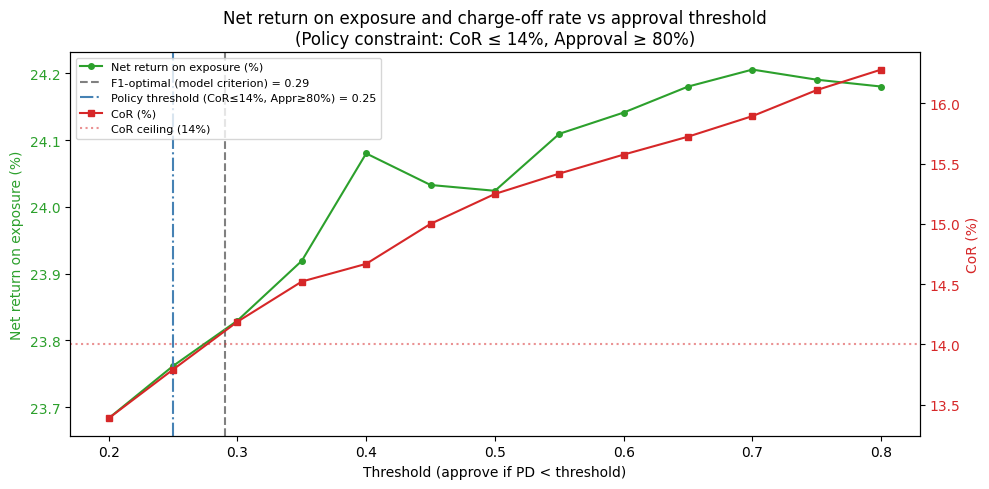

In [112]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sens_df["threshold"], sens_df["net_return"], color="tab:green", marker="o", markersize=4, label="Net return on exposure (%)")
ax1.set_xlabel("Threshold (approve if PD < threshold)")
ax1.set_ylabel("Net return on exposure (%)", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")

# F1-optimal threshold (model selection criterion, for reference)
ax1.axvline(x=best_threshold_opt, color="gray", linestyle="--",
            label=f"F1-optimal (model criterion) = {best_threshold_opt:.2f}")

# Policy-constrained threshold (business operating point)
if 'policy_threshold' in dir() and policy_threshold != best_threshold_opt:
    ax1.axvline(x=policy_threshold, color="steelblue", linestyle="-.",
                label=f"Policy threshold (CoR≤{COR_CEILING:.0%}, Appr≥{APPROVAL_FLOOR:.0%}) = {policy_threshold:.2f}")

ax2 = ax1.twinx()
ax2.plot(sens_df["threshold"], sens_df["CoR"] * 100, color="tab:red", marker="s", markersize=4, label="CoR (%)")
ax2.axhline(y=COR_CEILING * 100, color="tab:red", linestyle=":", alpha=0.5, label=f"CoR ceiling ({COR_CEILING:.0%})")
ax2.set_ylabel("CoR (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

plt.title("Net return on exposure and charge-off rate vs approval threshold\n"
          f"(Policy constraint: CoR ≤ {COR_CEILING:.0%}, Approval ≥ {APPROVAL_FLOOR:.0%})")
plt.tight_layout()
plt.show()


### Part II – 6. Baseline vs model – business case ($)

Compare $ approved (baseline vs model), $ charge-offs saved, and net return on exposure improvement in percentage points.


In [113]:
def _net_return_from_stats(stats: dict, cost_of_funds: float) -> float:
    approved_amnt = float(stats.get("approved_amnt", 0.0))
    if approved_amnt <= 0:
        return 0.0

    wgt_int_rate = float(stats.get("wgt_int_rate", 0.0))
    wgt_term = float(stats.get("wgt_term", 0.0))
    if wgt_term <= 0:
        import warnings
        warnings.warn(
            "wgt_term is 0 -- net return calculation will be zero (no term, no interest). "
            "Check that loan term data is present in the parquet.",
            UserWarning,
        )
        return 0.0
    charge_off_amnt = float(stats.get("charged_off_amnt", 0.0))

    interest_earned = approved_amnt * (wgt_int_rate / 100.0) * (wgt_term / 12.0)
    interest_paid = approved_amnt * (cost_of_funds / 100.0) * (wgt_term / 12.0)
    banking_profit = interest_earned - interest_paid - charge_off_amnt
    # NOTE: cumulative over wgt_term months. Divide by (wgt_term/12) for annualised equivalent.
    return (banking_profit / approved_amnt) * 100.0

net_ret_baseline_pct = _net_return_from_stats(baseline_stats, COST_OF_FUNDS)
net_ret_model_pct = _net_return_from_stats(model_stats, COST_OF_FUNDS)

approved_baseline = float(baseline_stats["approved_amnt"])
approved_model = float(model_stats["approved_amnt"])
charged_off_baseline = float(baseline_stats["charged_off_amnt"])
charged_off_model = float(model_stats["charged_off_amnt"])
saved_charge_off = charged_off_baseline - charged_off_model
net_ret_improvement_pp = net_ret_model_pct - net_ret_baseline_pct

term_yrs_baseline = (baseline_stats["wgt_term"] / 12) if baseline_stats["wgt_term"] > 0 else 1.0
term_yrs_model = (model_stats["wgt_term"] / 12) if model_stats["wgt_term"] > 0 else 1.0
print("Business case (test cohort)")
print(f"  $ Loans approved - Baseline: ${approved_baseline/1e6:.2f}m  |  Model: ${approved_model/1e6:.2f}m")
print(f"  $ Charge-offs saved (vs baseline): ${saved_charge_off/1e6:.2f}m")
print(f"  Net return (cumulative) - Baseline: {net_ret_baseline_pct:.2f}%  |  Model: {net_ret_model_pct:.2f}%  |  Improvement: {net_ret_improvement_pp:+.2f} pp")
print(f"  Net return (annualised) - Baseline: {net_ret_baseline_pct/term_yrs_baseline:.2f}%  |  Model: {net_ret_model_pct/term_yrs_model:.2f}%")


Business case (test cohort)
  $ Loans approved - Baseline: $261.68m  |  Model: $215.25m
  $ Charge-offs saved (vs baseline): $12.99m
  Net return (cumulative) - Baseline: 24.17%  |  Model: 23.84%  |  Improvement: -0.33 pp
  Net return (annualised) - Baseline: 6.07%  |  Model: 6.09%


In [114]:
# ── LGD break-even analysis ───────────────────────────────────────────────────
import numpy as np

def _net_return_at_lgd(stats, cost_of_funds, lgd):
    aa = float(stats["approved_amnt"])
    if aa <= 0:
        return 0.0
    co = float(stats["charged_off_amnt"]) * lgd
    ie = aa * (float(stats["wgt_int_rate"]) / 100) * (float(stats["wgt_term"]) / 12)
    ip = aa * (cost_of_funds / 100) * (float(stats["wgt_term"]) / 12)
    return (ie - ip - co) / aa * 100

lgd_grid = np.arange(0.10, 1.05, 0.05)
print(f"{'LGD':>6}  {'Baseline NR%':>13}  {'Model NR%':>10}  {'Delta pp':>9}  {'Model better?':>14}")
print("-" * 60)
_breakeven_lgd = None
for _lgd in lgd_grid:
    _nr_base = _net_return_at_lgd(baseline_stats, COST_OF_FUNDS, _lgd)
    _nr_model = _net_return_at_lgd(model_stats, COST_OF_FUNDS, _lgd)
    _delta = _nr_model - _nr_base
    _better = "Yes" if _delta > 0 else "No"
    print(f"{_lgd:>6.0%}  {_nr_base:>13.2f}%  {_nr_model:>10.2f}%  {_delta:>+9.2f}pp  {_better:>14}")
    if _breakeven_lgd is None and _delta <= 0:
        _breakeven_lgd = _lgd
print()
if _breakeven_lgd is not None:
    print(f"Break-even LGD: ~{_breakeven_lgd:.0%}.")
    print(f"Below {_breakeven_lgd:.0%} LGD (high recovery), approval-rate reduction costs more than")
    print("charge-off savings — baseline (approve-all) outperforms on net return.")
    print(f"Above {_breakeven_lgd:.0%} LGD (low recovery), model approval screening is value-accretive.")
else:
    print("Model is net-return-positive vs baseline across the full LGD range tested.")

   LGD   Baseline NR%   Model NR%   Delta pp   Model better?
------------------------------------------------------------
   10%          39.09%       36.54%      -2.55pp              No
   15%          38.26%       35.83%      -2.43pp              No
   20%          37.43%       35.13%      -2.30pp              No
   25%          36.60%       34.42%      -2.18pp              No
   30%          35.77%       33.72%      -2.06pp              No
   35%          34.94%       33.01%      -1.93pp              No
   40%          34.12%       32.31%      -1.81pp              No
   45%          33.29%       31.60%      -1.69pp              No
   50%          32.46%       30.89%      -1.56pp              No
   55%          31.63%       30.19%      -1.44pp              No
   60%          30.80%       29.48%      -1.32pp              No
   65%          29.97%       28.78%      -1.19pp              No
   70%          29.14%       28.07%      -1.07pp              No
   75%          28.32%       27.3

### Part II – 7. Summary (LendingClub)

*Run the cell below to print a one-paragraph summary with the key numbers from this run.*

**Threshold governance note:** For production model governance (aligned with MAS TRM
guidelines and SR 11-7 model risk principles), the approval threshold should be
selected on a held-out **validation set** and the final policy performance reported
once on an untouched OOT cohort. In this demo, `best_threshold_opt` was selected
by maximising F1 on the training/validation split inside `02a_pd_xgboost_training.ipynb`
and is used here for illustrative purposes only. The OOT metrics reported below
(AUC, KS, Brier) are evaluated on a strictly held-out OOT cohort and are not
subject to threshold leakage — only the *threshold value* itself was tuned on
in-sample data. In a production setting, threshold recalibration would follow
a separate validation governance cycle (e.g. Champion-Challenger framework).

---

## Model validation & back-testing

Out-of-time (OOT) validation ensures the model generalises to unseen data. The test split is held out temporally or by application cohort.

**Metric interpretation:** AUC-ROC measures rank-ordering (ability to separate good vs bad); 0.5 = random, 1.0 = perfect. KS (Kolmogorov–Smirnov) measures maximum separation between score distributions of defaulters vs non-defaulters. Brier score measures calibration (accuracy of PD point estimates); lower is better for provisioning. Gini = 2×AUC − 1.

**Threshold selection:** Thresholds should be aligned to economic policy objectives (e.g., maximise expected banking profit subject to CoR/approval constraints). For strict governance, tune on validation and report final performance once on untouched OOT; the sensitivity table supports this trade-off analysis.


In [115]:
from sklearn.metrics import roc_auc_score, brier_score_loss
try:
    from IPython.display import display
except ImportError:
    display = print

oot_auc = roc_auc_score(y_test, p_test)
oot_brier = brier_score_loss(y_test, p_test)
from scipy.stats import ks_2samp
oot_ks = ks_2samp(p_test[y_test == 0], p_test[y_test == 1]).statistic

meta_path = ROOT / "models" / "pd" / "training_meta.json"
meta = {}
if meta_path.exists():
    import json
    with open(meta_path) as f:
        meta = json.load(f)

val_tbl = pd.DataFrame([
    {"Metric": "OOT AUC-ROC", "Value": f"{oot_auc:.3f}"},
    {"Metric": "OOT KS", "Value": f"{oot_ks:.3f}"},
    {"Metric": "OOT Brier (lower = better calibration)", "Value": f"{oot_brier:.3f}"},
])
v = meta.get("stack_oot_auc")
if isinstance(v, (int, float)):
    val_tbl = pd.concat([val_tbl, pd.DataFrame([{"Metric": "Stack OOT AUC (training run)", "Value": f"{v:.3f}"}])], ignore_index=True)
display(val_tbl)

,Metric,Value
0,OOT AUC-ROC,0.645
1,OOT KS,0.212
2,OOT Brier (lower = better calibration),0.143
3,Stack OOT AUC (training run),0.645


## Expected Credit Loss (ECL) & provisioning

ECL = PD × LGD × EAD per exposure. For provisioning and capital planning, portfolio
ECL is the sum of expected losses across the approved book.

**IFRS 9 staging framework:**

| Stage | Trigger | PD horizon | ECL measure |
|---|---|---|---|
| Stage 1 | No significant credit deterioration since origination | 12-month PD | 12-month ECL |
| Stage 2 | Significant increase in credit risk (SICR) | Lifetime PD | Lifetime ECL |
| Stage 3 | Credit-impaired (default / 90+ DPD) | Lifetime PD | Lifetime ECL |

**This demo computes Stage 1 (12-month) ECL only.** The model outputs a 12-month
PD estimate, which is the correct input for Stage 1 performing loans.

For a 36-month loan term, the full IFRS 9 treatment would require:
- **Stage 1**: 12-month ECL as computed below (appropriate for low-risk approved book)
- **Stage 2**: Lifetime ECL using a survival-curve PD trajectory over remaining term
  (requires cohort-level PD term structure, not available from a single-point model)
- **Stage 3**: Lifetime ECL with specific provision based on collateral and recovery estimates

**LGD assumption:** 100% (no recovery) — conservative. Institution-specific LGD
from historical recovery data would reduce provisioning for secured/partially-secured loans.

**EAD:** Loan principal (`loan_amnt`) for drawn facilities. For revolving products
(credit cards), EAD would incorporate credit conversion factors (CCF) on undrawn limits.

**MAS context:** MAS Notice 612 (Credit Risk) and MAS Guidelines on Stress Testing
require banks to maintain adequate provisions aligned with IFRS 9. The simplified
Stage 1 ECL below is illustrative; production provisioning would be reviewed by
model validation and internal audit teams.


In [116]:
LGD_ASSUMED = 1.0  # 100% loss given default (conservative)
loans_df_ecl = loans_df.reset_index(drop=True)
p_test_arr = np.asarray(p_test).ravel()
approved_mask = p_test_arr < best_threshold_opt

ecl_per_loan = p_test_arr[approved_mask] * LGD_ASSUMED * loans_df_ecl.loc[approved_mask, "loan_amnt"].values
ecl_portfolio = ecl_per_loan.sum()
approved_amnt = loans_df_ecl.loc[approved_mask, "loan_amnt"].sum()
ecl_rate = ecl_portfolio / approved_amnt * 100 if approved_amnt else 0
print(f"Approved portfolio ECL (1-year, Stage 1): ${ecl_portfolio/1e6:.2f}m")
print(f"ECL as % of approved exposure: {ecl_rate:.2f}%")
print(f"(LGD assumption: {LGD_ASSUMED*100:.0f}% -- conservative/zero recovery. "
      f"Institution-specific LGD would reduce this.)")


Approved portfolio ECL (1-year, Stage 1): $13.25m
ECL as % of approved exposure: 6.16%
(LGD assumption: 100% -- conservative/zero recovery. Institution-specific LGD would reduce this.)


## Feature engineering, model governance & monitoring

**Feature sources:** Structured data from application forms, bureau, and payment history. Notebooks `01_pd_lendingclub_feature_engineering.ipynb` and `00_pd_homecredit_lstm_kaggle.ipynb` build ratios, trends, and sequence features. The platform also supports alternative data (e.g. document text via RAG, NLP sentiment) for enrichment.

**Model types:** Part I uses a **behavioral model** (LSTM on repayment sequences); Part II uses an **application scorecard** (XGBoost/LR on static features). Both support PD estimation for direct lending.

**Governance & regulatory:** Model versioning (`pd_model_local_v2.pkl`, `training_meta.json`), prompt registry for LLM memos, and audit trail from data → features → model → decision. Aligns with MAS Technology Risk Management and model risk guidelines.

**Monitoring & recalibration:** Drift detection (KS, population stability) in `credit_risk/monitoring/`. Recalibration triggers: KS drift, population shift, or scheduled review.

In [117]:
# ── Summary narrative ────────────────────────────────────────────────────────
_cor_improved  = model_stats["CoR"] < baseline_stats["CoR"]
_ret_improved  = net_ret_improvement_pp > 0
_co_saved      = saved_charge_off > 0

if _ret_improved and _cor_improved:
    net_ret_phrase = (
        f"improving net return on exposure from {net_ret_baseline_pct:.1f}% to "
        f"{net_ret_model_pct:.1f}% (+{net_ret_improvement_pp:.1f} pp)"
    )
elif _cor_improved and not _ret_improved:
    net_ret_phrase = (
        f"reducing CoR but with lower net return on exposure ({net_ret_baseline_pct:.1f}% → "
        f"{net_ret_model_pct:.1f}%, {net_ret_improvement_pp:.1f} pp) — "
        f"volume reduction from tighter approval more than offsets charge-off savings at this threshold"
    )
else:
    net_ret_phrase = (
        f"changing net return from {net_ret_baseline_pct:.1f}% to {net_ret_model_pct:.1f}% "
        f"({net_ret_improvement_pp:+.1f} pp)"
    )

_co_phrase = (
    f"saving approximately ${saved_charge_off/1e6:.1f}m in charge-offs on the test cohort"
    if _co_saved else
    f"charge-offs unchanged or marginally higher (model approved riskier mix at this threshold)"
)

summary = (
    f"At threshold {best_threshold_opt:.2f}, the model approves "
    f"{model_stats['approval_rate']:.0%} of applications (baseline: 100%), "
    f"reducing CoR from {baseline_stats['CoR']:.1%} to {model_stats['CoR']:.1%}, "
    f"{net_ret_phrase}, "
    f"{_co_phrase}."
)
print(summary)


At threshold 0.29, the model approves 85% of applications (baseline: 100%), reducing CoR from 16.6% to 14.1%, reducing CoR but with lower net return on exposure (24.2% → 23.8%, -0.3 pp) — volume reduction from tighter approval more than offsets charge-off savings at this threshold, saving approximately $13.0m in charge-offs on the test cohort.


## Executive summary

*Run the cell below for a consolidated summary of both Part I and Part II.*

In [118]:
print("Executive summary")
print("=" * 60)
print("Part II (LendingClub — Application Scorecard):")
print(f"  • OOT AUC-ROC : {oot_auc:.3f} | KS: {oot_ks:.3f} | Brier: {oot_brier:.3f}")
print(f"  • Charge-offs saved vs baseline    : ${saved_charge_off/1e6:.2f}m")
print(f"  • Net return on exposure (baseline): {net_ret_baseline_pct:.2f}%")
print(f"  • Net return on exposure (model)   : {net_ret_model_pct:.2f}%")
print(f"  • Net return improvement           : {net_ret_improvement_pp:+.2f} pp")
print(f"  • ECL (1-year, Stage 1)            : ${ecl_portfolio/1e6:.2f}m ({ecl_rate:.2f}% of approved)")
# Build threshold label based on governance check outcome
_thresh_label = "val-set max F1"
if "val_derived_threshold" in dir():
    _diff = abs(val_derived_threshold - best_threshold_opt)
    if _diff > 0.05:
        _thresh_label = f"artefact (WARNING: val-derived={val_derived_threshold:.2f}, diff={_diff:.2f}pp)"
    else:
        _thresh_label = f"val-set max F1 (verified, val-derived={val_derived_threshold:.2f})"

print(f"  • Threshold (F1-optimal, {_thresh_label}): {best_threshold_opt:.2f}")
if 'policy_threshold' in dir() and policy_threshold != best_threshold_opt:
    print(f"  • Policy threshold (CoR/approval constrained): {policy_threshold:.2f}")
print()
print("  NOTE: 'Net return on exposure' = (interest earned − cost of funds − charge-offs)")
print("        / approved exposure. This is a NIM proxy, not capital-based RoE.")
print()
print("Part I (Home Credit — Behavioral LSTM):")
print("  Run 00_pd_homecredit_lstm_kaggle.ipynb on Kaggle for LSTM metrics.")
print("=" * 60)


Executive summary
Part II (LendingClub — Application Scorecard):
  • OOT AUC-ROC : 0.645 | KS: 0.212 | Brier: 0.143
  • Charge-offs saved vs baseline    : $12.99m
  • Net return on exposure (baseline): 24.17%
  • Net return on exposure (model)   : 23.84%
  • Net return improvement           : -0.33 pp
  • ECL (1-year, Stage 1)            : $13.25m (6.16% of approved)
  • Threshold (F1-optimal, val-set max F1 (verified, val-derived=0.29)): 0.29
  • Policy threshold (CoR/approval constrained): 0.25

  NOTE: 'Net return on exposure' = (interest earned − cost of funds − charge-offs)
        / approved exposure. This is a NIM proxy, not capital-based RoE.

Part I (Home Credit — Behavioral LSTM):
  Run 00_pd_homecredit_lstm_kaggle.ipynb on Kaggle for LSTM metrics.
